# Bad Crop Filter Analysis

**目标**: 分析 bad crop score 过滤前后，Image 的 good rate 变化（区分 Internal / 其他类型）

**数据说明**:
- **Score 文件**: `bad_crop_score.txt` — 每张图片的 bad crop 分数
- **Label 文件**: UHRS TSV — 3个judge对每张图片投票，使用 `FinalDecision` 列 (Good/Bad/Fair)

**规则**:
- Label 聚合: 3票中 **≥ 2票 Bad → Bad**，否则 Non-Bad
- Filter: bad_crop_score **< 0.1 保留**，≥ 0.1 过滤掉
- Good Rate = Non-Bad 图片数 / 总图片数
- 图片类型: 文件名以 `Internal` 开头 → **Internal**；其余 → **Other**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

SCORE_FILE = r"D:\Data\T2I\ZImage\official\LP200_0131-2_official_ZImage_images_cfg0_20260201-0426\bad_crop_score.txt"
LABEL_FILE = r"D:\Code\ms-image-quality-filters-aether-module-main\QwenFinetune\RawData\UHRS_Task_lp_quality_labeling_0204_LP200_0131-2_official_ZImage_images_cfg0_20260201-0426.tsv"
THRESHOLD = 0.1

## 1. 读取 Bad Crop Score 文件

In [2]:
score_rows = []
with open(SCORE_FILE, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        parts = line.split('\t')
        if len(parts) != 2:
            continue
        path_part, score_str = parts
        # path_part: "123→/full/path/file.png"
        full_path = path_part.split('\u2192', 1)[1] if '\u2192' in path_part else path_part
        filename = Path(full_path).name
        score_rows.append({'lp_id': filename, 'bad_crop_score': float(score_str)})

df_score = pd.DataFrame(score_rows)
print(f"Score 文件共 {len(df_score)} 条记录")
print(f"Score 范围: min={df_score['bad_crop_score'].min():.4f}, max={df_score['bad_crop_score'].max():.4f}, mean={df_score['bad_crop_score'].mean():.4f}")
df_score.head()

Score 文件共 1000 条记录
Score 范围: min=0.0180, max=0.6895, mean=0.0585


,lp_id,bad_crop_score
0,Internal100100_Prompt1.png,0.038025
1,Internal100100_Prompt2.png,0.024948
2,Internal100100_Prompt3.png,0.023651
3,Internal100100_Prompt4.png,0.021408
4,Internal100100_Prompt5.png,0.024429


## 2. 读取 Label 文件并聚合投票

In [3]:
df_label = pd.read_csv(LABEL_FILE, sep='\t', dtype=str)
print(f"Label 文件共 {len(df_label)} 行（每张图片3个judge投票）")
print("\nFinalDecision 原始取值分布:")
print(df_label['FinalDecision'].value_counts())
df_label[['lp_id', 'JudgeID', 'FinalDecision']].head(9)

Label 文件共 3000 行（每张图片3个judge投票）

FinalDecision 原始取值分布:
FinalDecision
Good             1867
Bad               605
Fair              525
Imageloadfail       2
Logo                1
Name: count, dtype: int64


,lp_id,JudgeID,FinalDecision
0,Random10046_Prompt5.png,1628038,Fair
1,Internal10082_Prompt4.png,1628038,Good
2,Internal10028_Prompt3.png,1628038,Good
3,Random10044_Prompt4.png,1628038,Good
4,Internal10029_Prompt2.png,1628038,Good
5,Internal10063_Prompt3.png,1628038,Good
6,Random10038_Prompt4.png,1628038,Bad
7,Internal10034_Prompt3.png,1628038,Bad
8,Random10041_Prompt4.png,1628038,Fair


In [4]:
# 统一大小写，聚合投票：>=2票 Bad -> bad
df_label['FinalDecision_norm'] = df_label['FinalDecision'].str.strip().str.lower()

def aggregate_votes(group):
    decisions = group['FinalDecision_norm'].tolist()
    bad_votes = sum(1 for d in decisions if d == 'bad')
    final_label = 'bad' if bad_votes >= 2 else 'non-bad'
    return pd.Series({'bad_votes': bad_votes, 'total_votes': len(decisions), 'agg_label': final_label})

# 只传入需要的列，避免 include_groups 兼容问题
df_agg = df_label[['lp_id', 'FinalDecision_norm']].groupby('lp_id').apply(aggregate_votes).reset_index()
print(f"聚合后共 {len(df_agg)} 张图片")
print("\n聚合标签分布:")
print(df_agg['agg_label'].value_counts())
print("\nbad_votes 分布 (0~3):")
print(df_agg['bad_votes'].value_counts().sort_index())

聚合后共 1000 张图片



聚合标签分布:
agg_label
non-bad    863
bad        137
Name: count, dtype: int64

bad_votes 分布 (0~3):
bad_votes
0    555
1    308
2    114
3     23
Name: count, dtype: int64


## 3. 合并 Score 与 Label，添加图片类型

In [5]:
df = pd.merge(df_score, df_agg[['lp_id', 'bad_votes', 'total_votes', 'agg_label']], on='lp_id', how='inner')
print(f"合并后共 {len(df)} 张图片")
print(f"Score 文件未匹配: {len(df_score) - len(df)} 张")
print(f"Label 文件未匹配: {len(df_agg) - len(df)} 张")

# 图片类型：Internal vs Other
df['img_type'] = df['lp_id'].apply(lambda x: 'Internal' if x.startswith('Internal') else 'Other')
print("\n图片类型分布:")
print(df['img_type'].value_counts())
df.head()

合并后共 1000 张图片
Score 文件未匹配: 0 张
Label 文件未匹配: 0 张

图片类型分布:
img_type
Internal    500
Other       500
Name: count, dtype: int64


,lp_id,bad_crop_score,bad_votes,total_votes,agg_label,img_type
0,Internal100100_Prompt1.png,0.038025,3,3,bad,Internal
1,Internal100100_Prompt2.png,0.024948,1,3,non-bad,Internal
2,Internal100100_Prompt3.png,0.023651,0,3,non-bad,Internal
3,Internal100100_Prompt4.png,0.021408,2,3,bad,Internal
4,Internal100100_Prompt5.png,0.024429,1,3,non-bad,Internal


## 4. 计算 Filter 前后 Good Rate（Overall + 分类型）

In [6]:
df['pass_filter'] = df['bad_crop_score'] < THRESHOLD

def compute_good_rate(subdf):
    total = len(subdf)
    good = (subdf['agg_label'] == 'non-bad').sum()
    return good, total, good / total if total > 0 else 0

rows = []
for img_type in ['All', 'Internal', 'Other']:
    if img_type == 'All':
        subset = df
    else:
        subset = df[df['img_type'] == img_type]

    before_good, before_total, before_rate = compute_good_rate(subset)
    after_subset = subset[subset['pass_filter']]
    after_good, after_total, after_rate = compute_good_rate(after_subset)
    filtered_out = before_total - after_total

    rows.append({
        'Type': img_type,
        'Before_Total': before_total,
        'Before_Good': before_good,
        'Before_Bad': before_total - before_good,
        'Before_GoodRate': f'{before_rate:.2%}',
        'FilteredOut': filtered_out,
        'FilterRate': f'{filtered_out/before_total:.2%}' if before_total > 0 else '0%',
        'After_Total': after_total,
        'After_Good': after_good,
        'After_Bad': after_total - after_good,
        'After_GoodRate': f'{after_rate:.2%}',
        'Improvement': f'+{(after_rate - before_rate):.2%}'
    })

df_summary = pd.DataFrame(rows)
print(f'Bad Crop Threshold = {THRESHOLD}\n')
print(df_summary.to_string(index=False))

Bad Crop Threshold = 0.1

    Type  Before_Total  Before_Good  Before_Bad Before_GoodRate  FilteredOut FilterRate  After_Total  After_Good  After_Bad After_GoodRate Improvement
     All          1000          863         137          86.30%          108     10.80%          892         786        106         88.12%      +1.82%
Internal           500          426          74          85.20%           56     11.20%          444         388         56         87.39%      +2.19%
   Other           500          437          63          87.40%           52     10.40%          448         398         50         88.84%      +1.44%


## 5. 被过滤图片的 Label 分布（分类型）

In [7]:
df_out = df[~df['pass_filter']]
print(f"总过滤掉: {len(df_out)} 张 (score >= {THRESHOLD})\n")
for img_type in ['All', 'Internal', 'Other']:
    sub = df_out if img_type == 'All' else df_out[df_out['img_type'] == img_type]
    n = len(sub)
    if n == 0:
        print(f"[{img_type}] 无过滤图片")
        continue
    bad_n = (sub['agg_label'] == 'bad').sum()
    print(f"[{img_type}] 过滤掉 {n} 张: Bad={bad_n} ({bad_n/n:.2%}), Non-Bad={n-bad_n} ({(n-bad_n)/n:.2%})")

总过滤掉: 108 张 (score >= 0.1)

[All] 过滤掉 108 张: Bad=31 (28.70%), Non-Bad=77 (71.30%)
[Internal] 过滤掉 56 张: Bad=18 (32.14%), Non-Bad=38 (67.86%)
[Other] 过滤掉 52 张: Bad=13 (25.00%), Non-Bad=39 (75.00%)


## 6. 可视化

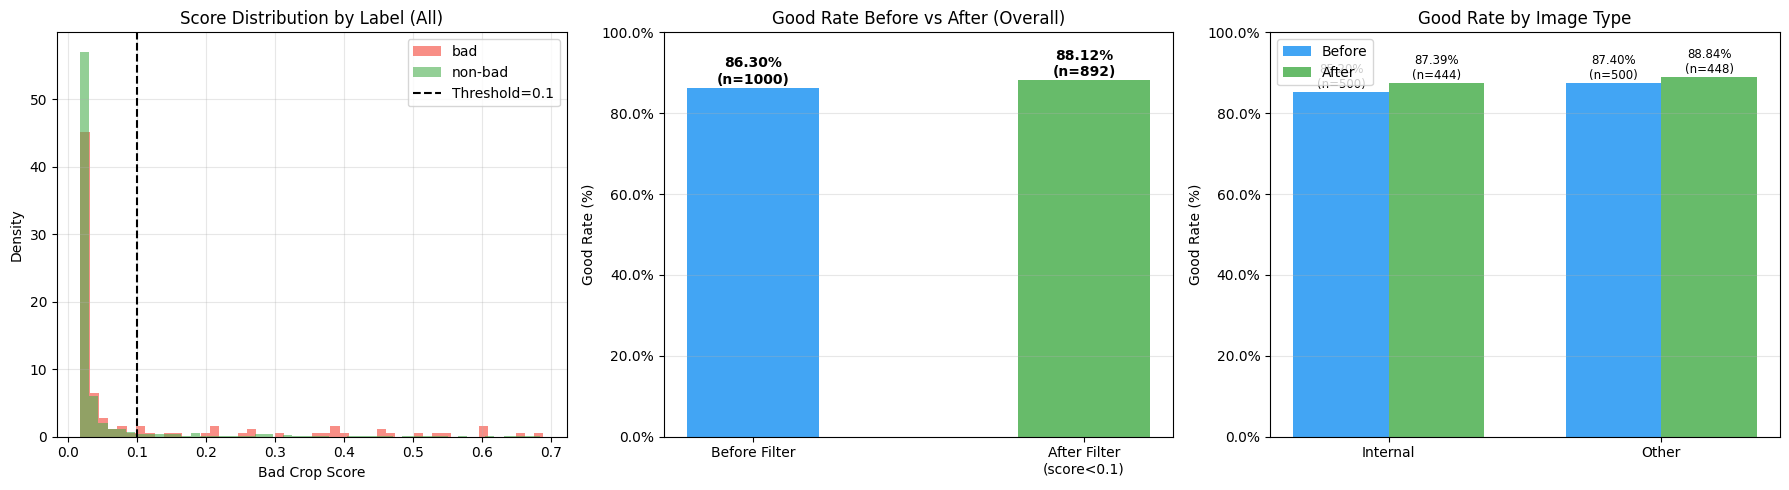

图表已保存: D:\Code\ms-image-quality-filters-aether-module-main\QwenFinetune\bad_crop_filter_analysis.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 左图: Score 分布 by label ---
ax = axes[0]
color_map = {'non-bad': '#4CAF50', 'bad': '#F44336'}
for lbl, grp in df.groupby('agg_label'):
    ax.hist(grp['bad_crop_score'], bins=50, alpha=0.6, label=lbl,
            color=color_map.get(lbl, 'gray'), density=True)
ax.axvline(THRESHOLD, color='black', linestyle='--', lw=1.5, label=f'Threshold={THRESHOLD}')
ax.set_xlabel('Bad Crop Score')
ax.set_ylabel('Density')
ax.set_title('Score Distribution by Label (All)')
ax.legend()
ax.grid(alpha=0.3)

# --- 中图: Good Rate Before/After (Overall) ---
ax2 = axes[1]
row_all = df_summary[df_summary['Type'] == 'All'].iloc[0]
before_rate_all = float(row_all['Before_GoodRate'].strip('%')) / 100
after_rate_all = float(row_all['After_GoodRate'].strip('%')) / 100
bars = ax2.bar(['Before Filter', f'After Filter\n(score<{THRESHOLD})'],
               [before_rate_all*100, after_rate_all*100],
               color=['#2196F3', '#4CAF50'], width=0.4, alpha=0.85)
for bar, rate, cnt in zip(bars,
                          [before_rate_all, after_rate_all],
                          [row_all['Before_Total'], row_all['After_Total']]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{rate:.2%}\n(n={cnt})', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_ylabel('Good Rate (%)')
ax2.set_title('Good Rate Before vs After (Overall)')
ax2.set_ylim(0, min(100, max(before_rate_all, after_rate_all)*100*1.18))
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax2.grid(axis='y', alpha=0.3)

# --- 右图: Good Rate Before/After by Type ---
ax3 = axes[2]
types = ['Internal', 'Other']
x = np.arange(len(types))
width = 0.35
before_rates = []
after_rates = []
before_counts = []
after_counts = []
for t in types:
    row = df_summary[df_summary['Type'] == t].iloc[0]
    before_rates.append(float(row['Before_GoodRate'].strip('%')) / 100)
    after_rates.append(float(row['After_GoodRate'].strip('%')) / 100)
    before_counts.append(row['Before_Total'])
    after_counts.append(row['After_Total'])

bars1 = ax3.bar(x - width/2, [r*100 for r in before_rates], width, label='Before', color='#2196F3', alpha=0.85)
bars2 = ax3.bar(x + width/2, [r*100 for r in after_rates], width, label='After', color='#4CAF50', alpha=0.85)
for bar, rate, cnt in zip(bars1, before_rates, before_counts):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f'{rate:.2%}\n(n={cnt})', ha='center', va='bottom', fontsize=8.5)
for bar, rate, cnt in zip(bars2, after_rates, after_counts):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f'{rate:.2%}\n(n={cnt})', ha='center', va='bottom', fontsize=8.5)
ax3.set_xticks(x)
ax3.set_xticklabels(types)
ax3.set_ylabel('Good Rate (%)')
ax3.set_title('Good Rate by Image Type')
ax3.set_ylim(0, min(100, max(before_rates + after_rates)*100*1.18))
ax3.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
out_fig = r"D:\Code\ms-image-quality-filters-aether-module-main\QwenFinetune\bad_crop_filter_analysis.png"
plt.savefig(out_fig, dpi=150, bbox_inches='tight')
plt.show()
print(f'图表已保存: {out_fig}')

## 7. 不同 Threshold 下 Good Rate 敏感性分析（分类型）

In [9]:
thresholds = [0.05, 0.08, 0.10, 0.12, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]
results = []
for thr in thresholds:
    for img_type in ['All', 'Internal', 'Other']:
        sub = df if img_type == 'All' else df[df['img_type'] == img_type]
        total_sub = len(sub)
        passed = sub[sub['bad_crop_score'] < thr]
        n = len(passed)
        n_good = (passed['agg_label'] == 'non-bad').sum()
        good_rate = n_good / n if n > 0 else 0
        results.append({
            'threshold': thr,
            'type': img_type,
            'remaining': n,
            'filter_rate': f'{(total_sub - n)/total_sub:.2%}' if total_sub > 0 else 'N/A',
            'good_rate': f'{good_rate:.2%}'
        })

df_sens = pd.DataFrame(results)
for img_type in ['All', 'Internal', 'Other']:
    print(f'\n=== {img_type} ===' )
    print(df_sens[df_sens['type'] == img_type].drop(columns='type').to_string(index=False))


=== All ===
 threshold  remaining filter_rate good_rate
      0.05        836      16.40%    88.52%
      0.08        879      12.10%    88.17%
      0.10        892      10.80%    88.12%
      0.12        906       9.40%    87.86%
      0.15        915       8.50%    87.87%
      0.20        931       6.90%    87.97%
      0.25        943       5.70%    87.59%
      0.30        954       4.60%    87.53%
      0.40        968       3.20%    87.09%
      0.50        979       2.10%    86.82%

=== Internal ===
 threshold  remaining filter_rate good_rate
      0.05        418      16.40%    88.04%
      0.08        438      12.40%    87.44%
      0.10        444      11.20%    87.39%
      0.12        448      10.40%    87.05%
      0.15        453       9.40%    86.98%
      0.20        463       7.40%    87.04%
      0.25        471       5.80%    86.41%
      0.30        476       4.80%    86.13%
      0.40        483       3.40%    85.51%
      0.50        487       2.60%    85.42%

